In [1]:
!pip install -q kaggle

In [2]:
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset

Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 157M/157M [00:08<00:00, 19.2MB/s]



In [3]:
!unzip -q brain-tumor-mri-dataset.zip

In [4]:
!find /content -maxdepth 2 -type d

/content
/content/.config
/content/.config/configurations
/content/.config/logs
/content/Testing
/content/Testing/glioma
/content/Testing/notumor
/content/Testing/pituitary
/content/Testing/meningioma
/content/Training
/content/Training/glioma
/content/Training/notumor
/content/Training/pituitary
/content/Training/meningioma
/content/sample_data


In [5]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.layers import Rescaling

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [6]:
IMG_SIZE = (128,128)
BATCH_SIZE = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/Training",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/Testing",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 5600 files belonging to 4 classes.
Found 1600 files belonging to 4 classes.


In [7]:
class_names = train_ds.class_names

print("Classes:", class_names)

Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [8]:
normalization_layer = Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))

In [9]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

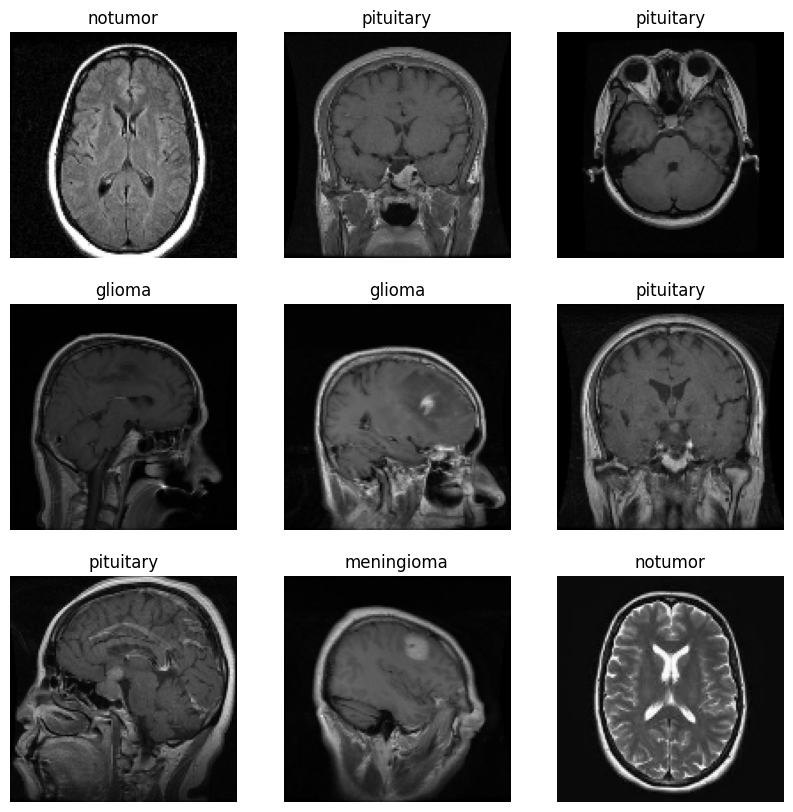

In [10]:
plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):

    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i])
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

In [11]:
model = Sequential()

model.add(Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(128,(3,3),activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(4,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,156 (12.61 MB)

 Trainable params: 3,305,156 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [14]:
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=10
)

Epoch 1/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 16s 56ms/step - accuracy: 0.6920 - loss: 0.7631 - val_accuracy: 0.7069 - val_loss: 0.9671
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.8257 - loss: 0.4604 - val_accuracy: 0.7506 - val_loss: 0.7682
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.8720 - loss: 0.3314 - val_accuracy: 0.8163 - val_loss: 0.7793
Epoch 4/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9020 - loss: 0.2557 - val_accuracy: 0.8300 - val_loss: 0.6298
Epoch 5/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9302 - loss: 0.1836 - val_accuracy: 0.8450 - val_loss: 0.7525
Epoch 6/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9425 - loss: 0.1512 - val_accuracy: 0.8706 - val_loss: 0.8126
Epoch 7/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9546 - loss: 0.1214 - val_accuracy: 0.8819 - val_loss: 0.8437
Epoch 8/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.9639 - loss: 0.0919 - val_acc

In [15]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9025 - loss: 0.8795
Test Accuracy: 0.9024999737739563
Test Loss: 0.8795070648193359


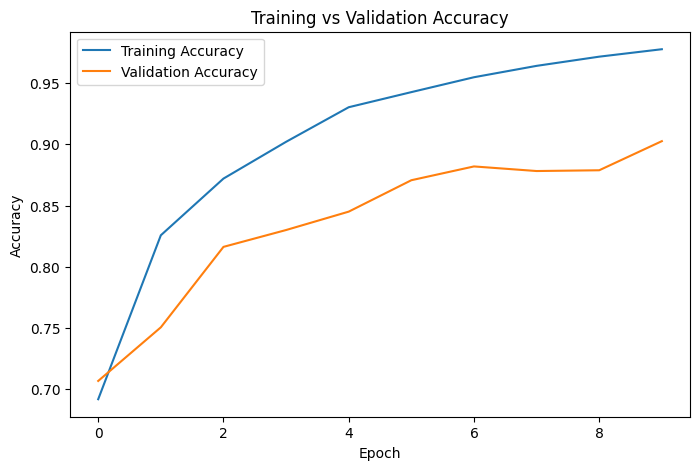

In [16]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.show()

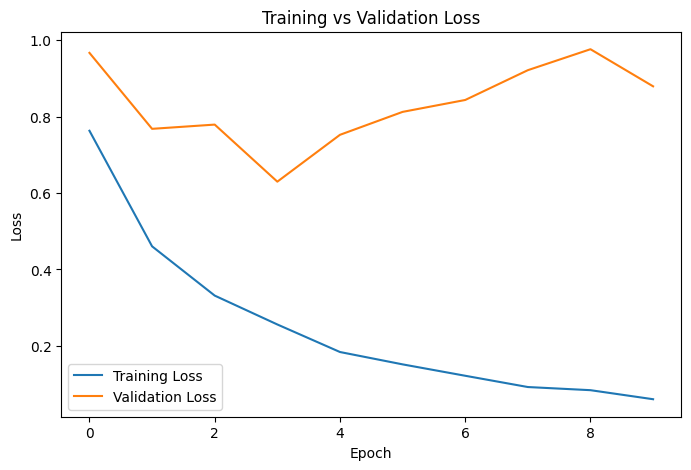

In [17]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

In [18]:
predictions = model.predict(test_ds)

predicted_labels = np.argmax(predictions, axis=1)

50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


In [19]:
true_labels = []

for images, labels in test_ds:
    true_labels.extend(labels.numpy())

true_labels = np.array(true_labels)

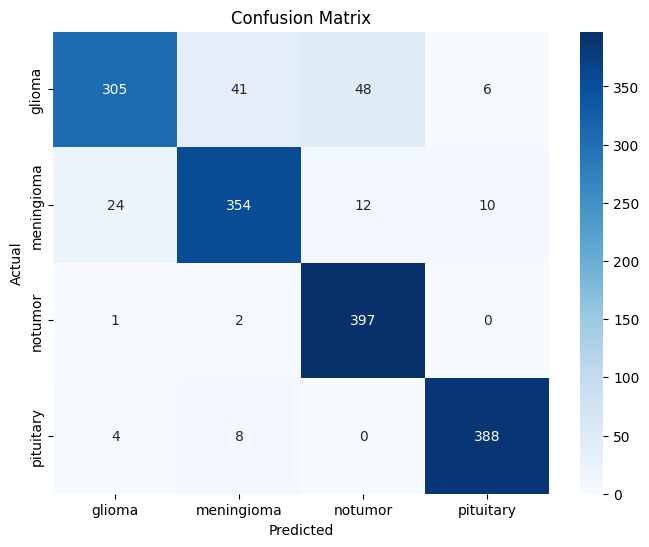

In [20]:
cm = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [21]:
print(classification_report(
    true_labels,
    predicted_labels,
    target_names=class_names
))

              precision    recall  f1-score   support

      glioma       0.91      0.76      0.83       400
  meningioma       0.87      0.89      0.88       400
     notumor       0.87      0.99      0.93       400
   pituitary       0.96      0.97      0.97       400

    accuracy                           0.90      1600
   macro avg       0.90      0.90      0.90      1600
weighted avg       0.90      0.90      0.90      1600



1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 682ms/step
Actual: glioma
Predicted: meningioma


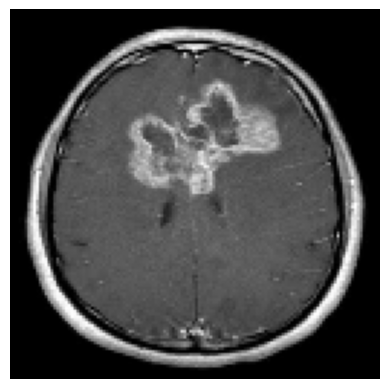

In [22]:
for images, labels in test_ds.take(1):

    plt.imshow(images[0])
    plt.axis("off")

    prediction = model.predict(tf.expand_dims(images[0], axis=0))

    predicted_class = class_names[np.argmax(prediction)]
    actual_class = class_names[labels[0]]

    print("Actual:", actual_class)
    print("Predicted:", predicted_class)